In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import numpy as np

In [40]:
df_new = pd.read_csv("tabular_data/baseline_data.csv", dtype={"oid": str})
df_old = pd.read_csv("tabular_data/baseline_data(old).csv", dtype={"oid": str})

In [70]:
alert_features = [
    "n_points_alert","mag_min_alert","mag_max_alert",
    "mag_p05_alert","mag_p25_alert","mag_p50_alert","mag_p75_alert","mag_p95_alert",
    "excess_variance_alert"
]
dr_features = [
    "n_points_dr","mag_min_dr","mag_max_dr",
    "mag_p05_dr","mag_p25_dr","mag_p50_dr","mag_p75_dr","mag_p95_dr",
    "excess_variance_dr"
]
delight_features = [
    "distance_delight", "hostsize"
]

In [71]:
def plot_good_bad(df, title, ax):
    if 'fid' in df.columns:
        counts = df.groupby(['fid', 'label']).size().unstack(fill_value=0)
        pct    = counts.div(counts.sum(axis=1), axis=0) * 100
        pct.plot(kind='bar', stacked=False, ax=ax)
        ax.set_xlabel('Canal (fid)')
        ax.set_ylabel('Porcentaje (%)')
    else:
        counts = df['label'].value_counts()
        pct    = counts / counts.sum() * 100
        pct.plot(kind='bar', ax=ax)
        ax.set_xlabel('Label')
        ax.set_ylabel('Porcentaje (%)')
    ax.set_title(title)
    ax.legend(title='Label')

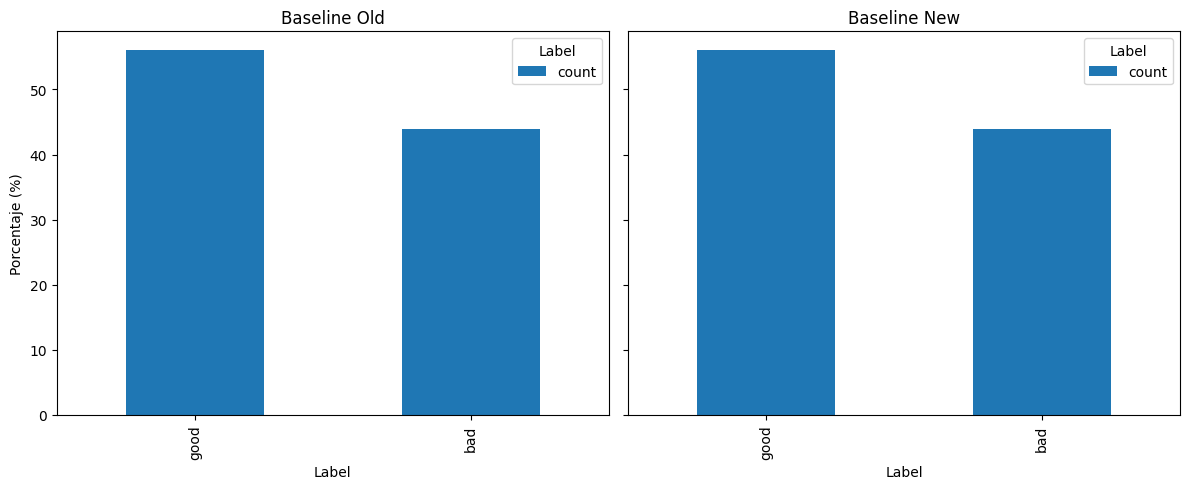

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

plot_good_bad(df_old, "Baseline Old", axes[0])
plot_good_bad(df_new, "Baseline New", axes[1])

plt.tight_layout()
plt.show()

In [73]:
def plot_hist_subplot(ax, df, fid, feature, title_suffix):
    sub = df[df["fid"] == fid]
    for label in ["good", "bad"]:
        data = sub[sub["label"] == label][feature].dropna()
        ax.hist(data, bins=30, density=True, alpha=0.5, label=label)
    ax.set_title(f"{title_suffix} — Canal {fid}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Densidad")
    ax.legend()

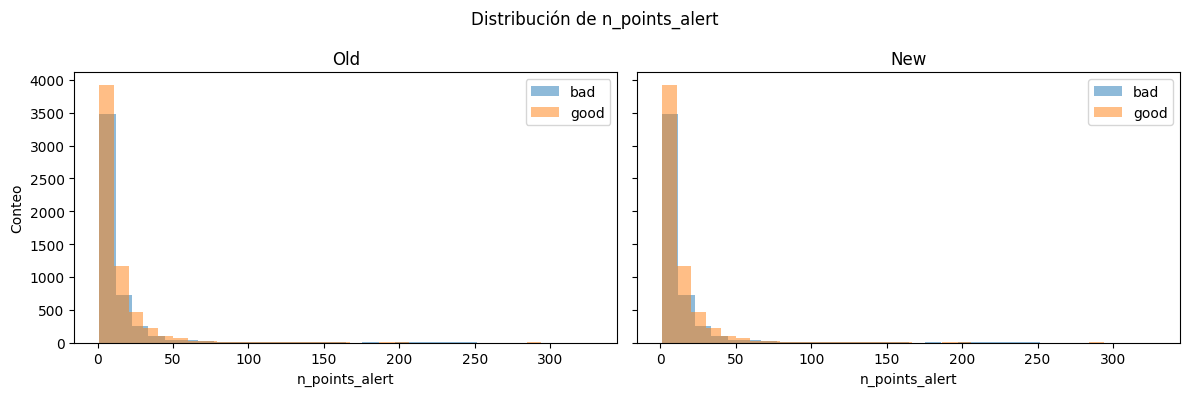

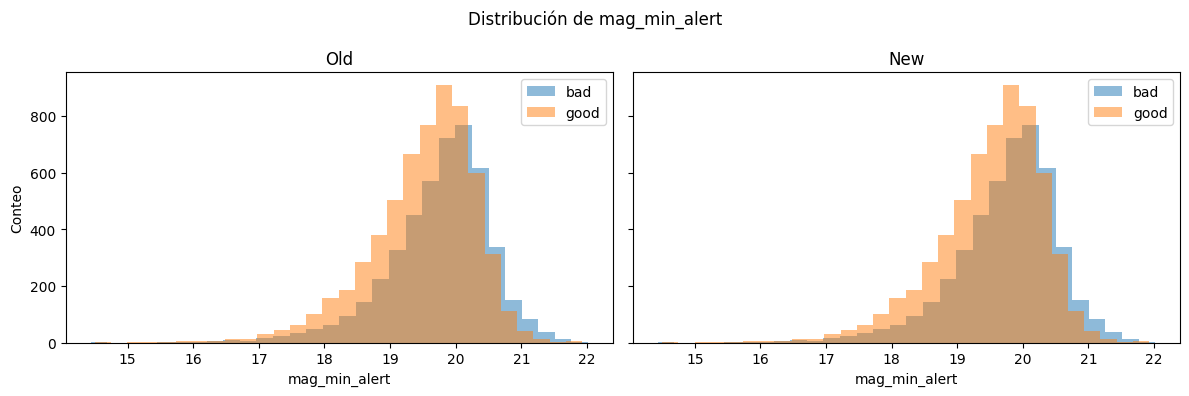

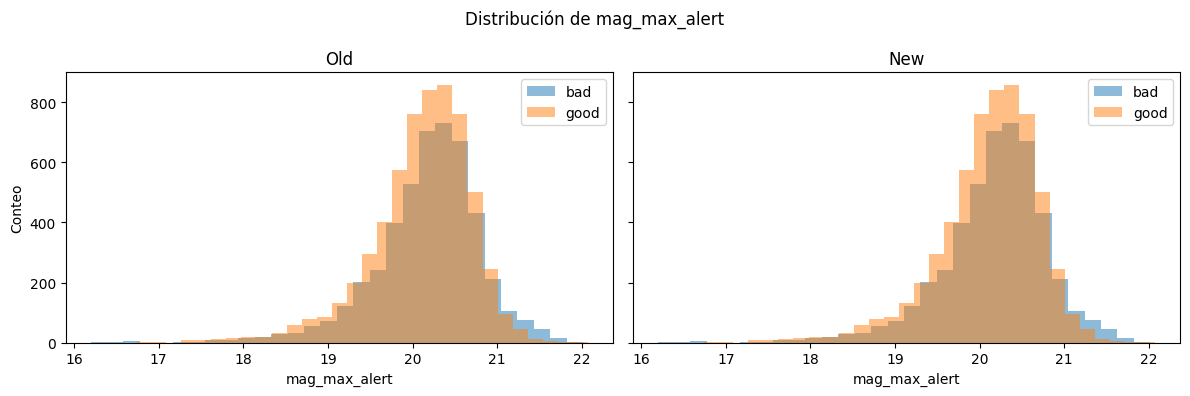

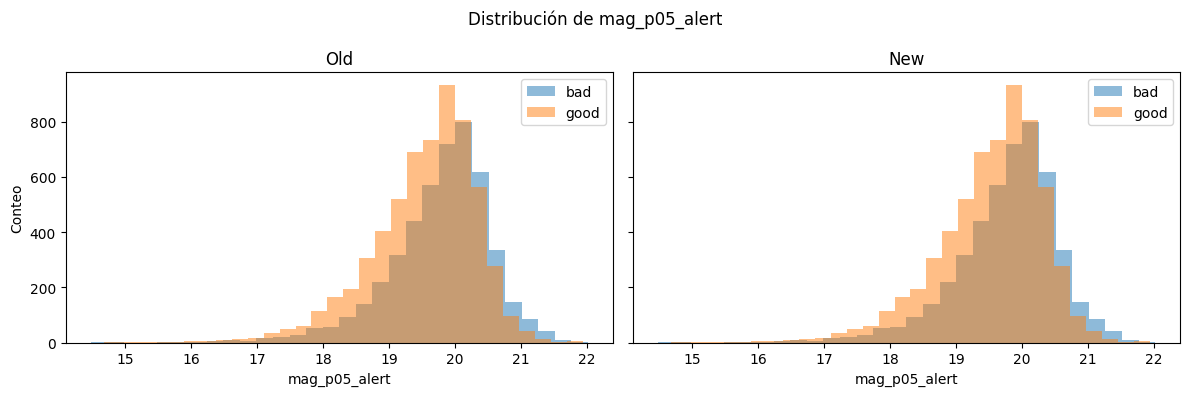

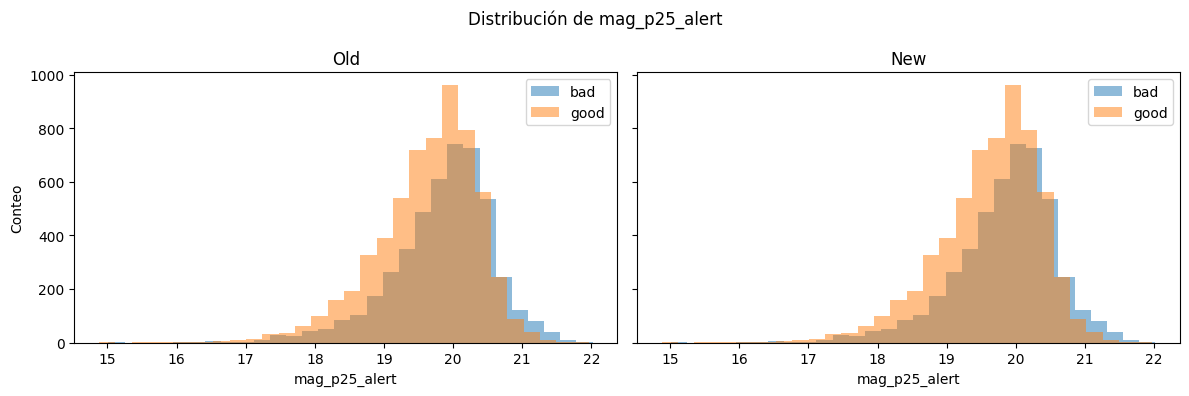

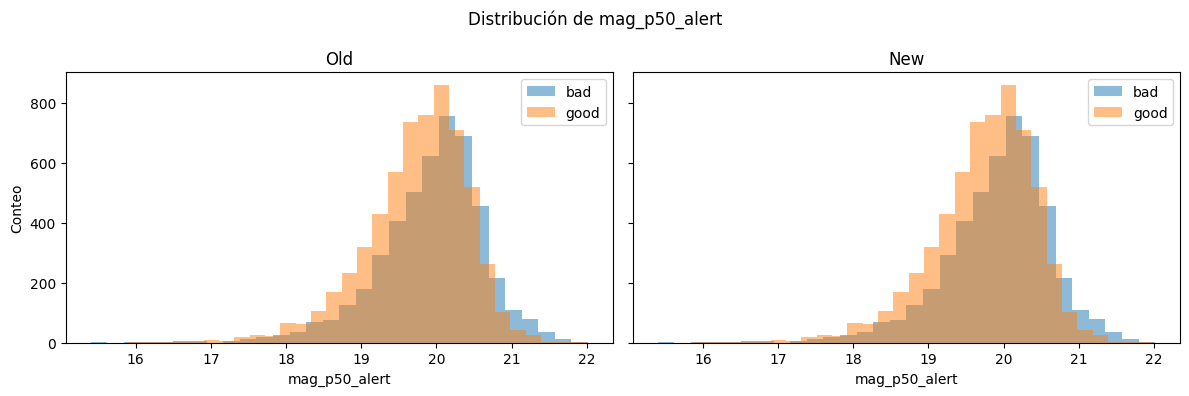

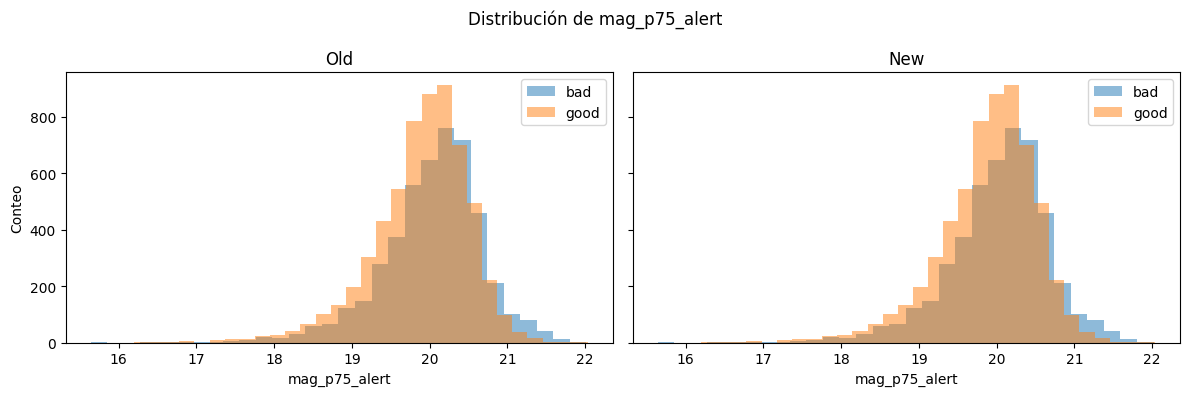

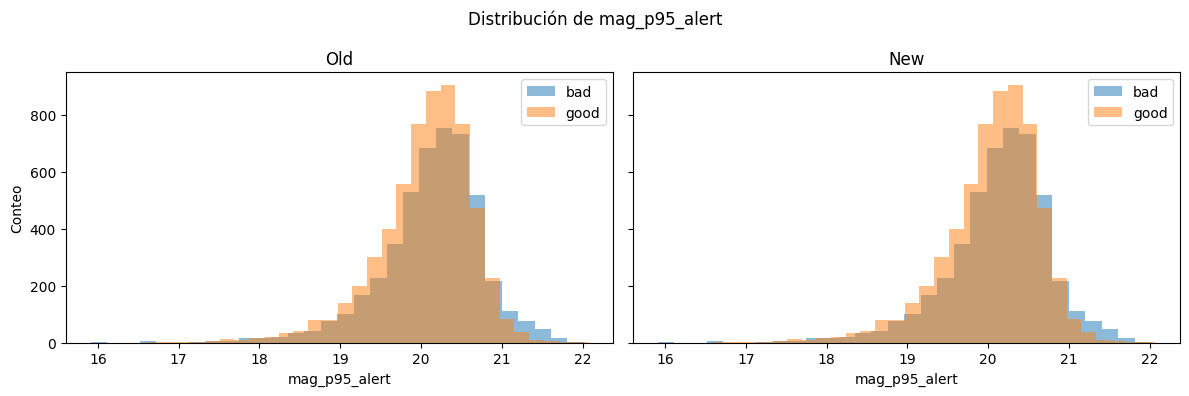

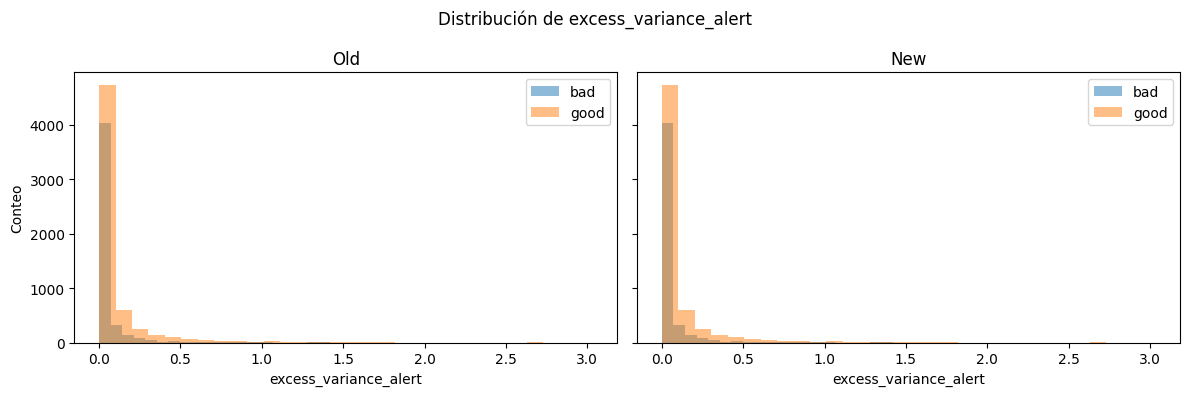

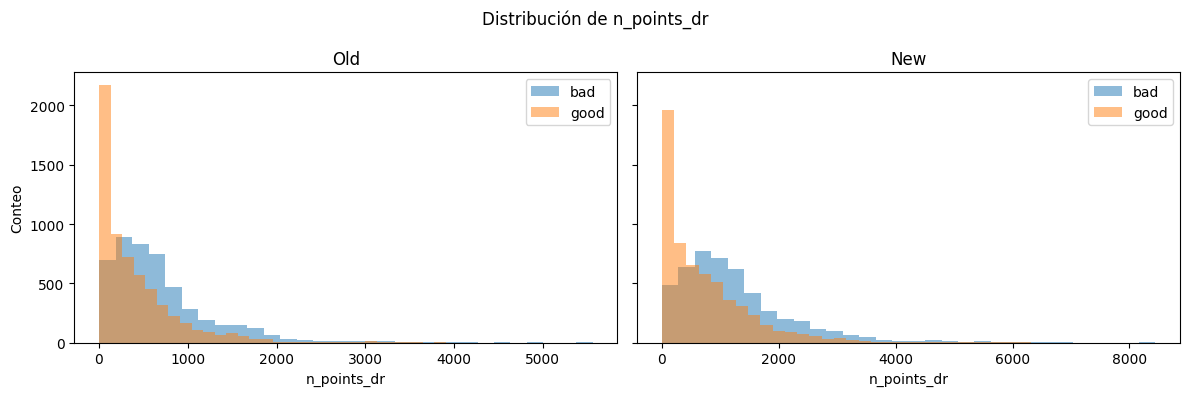

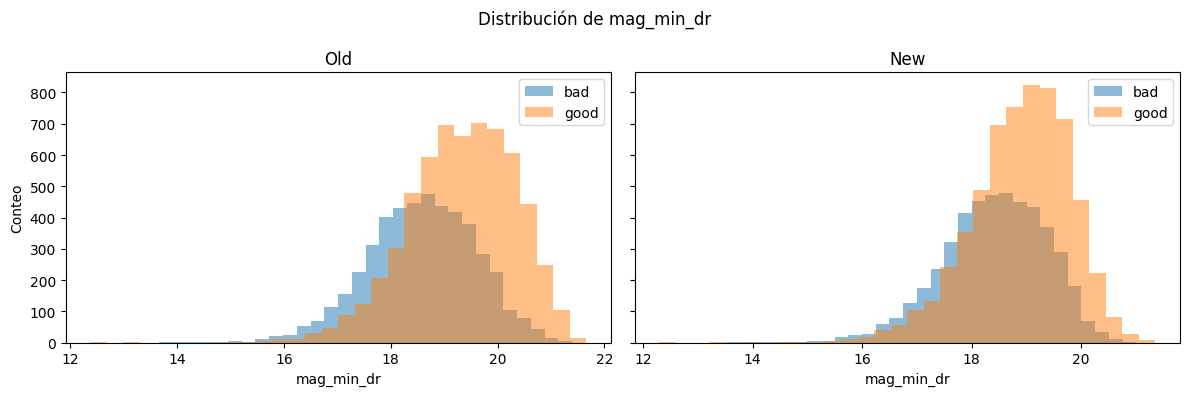

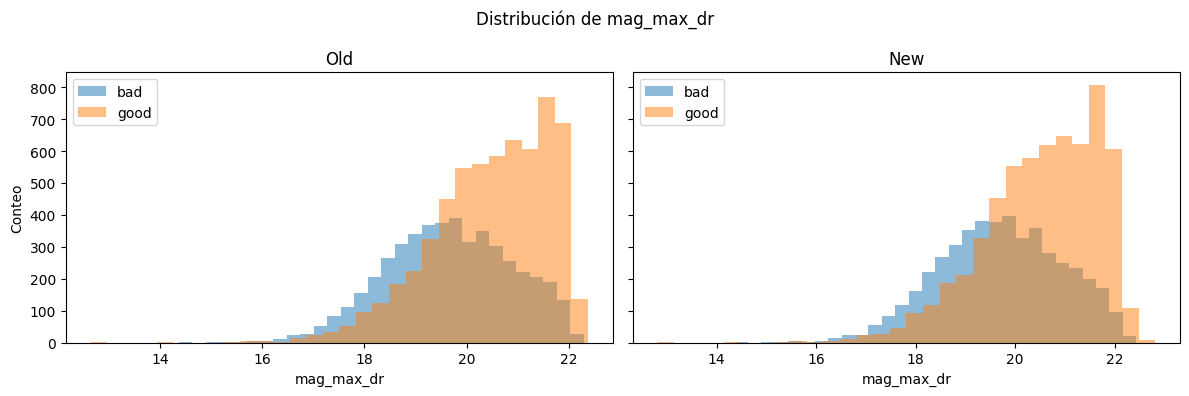

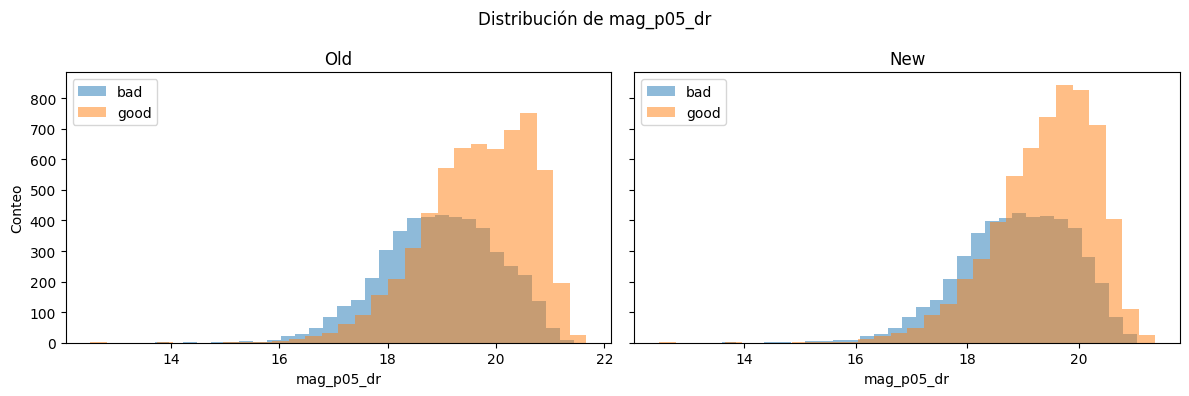

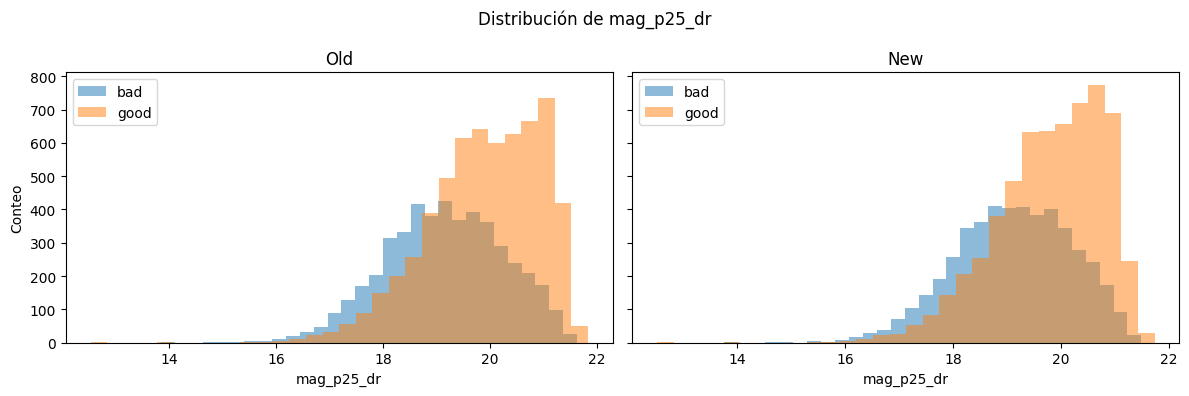

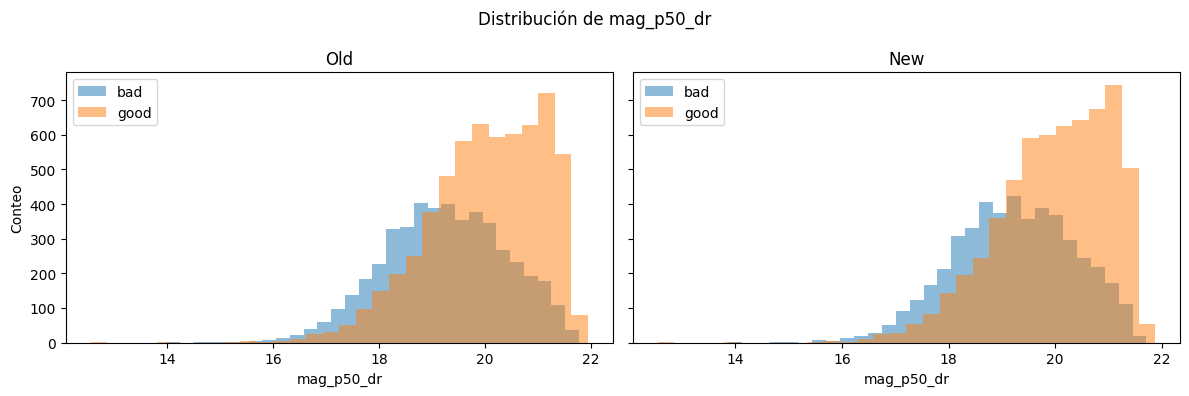

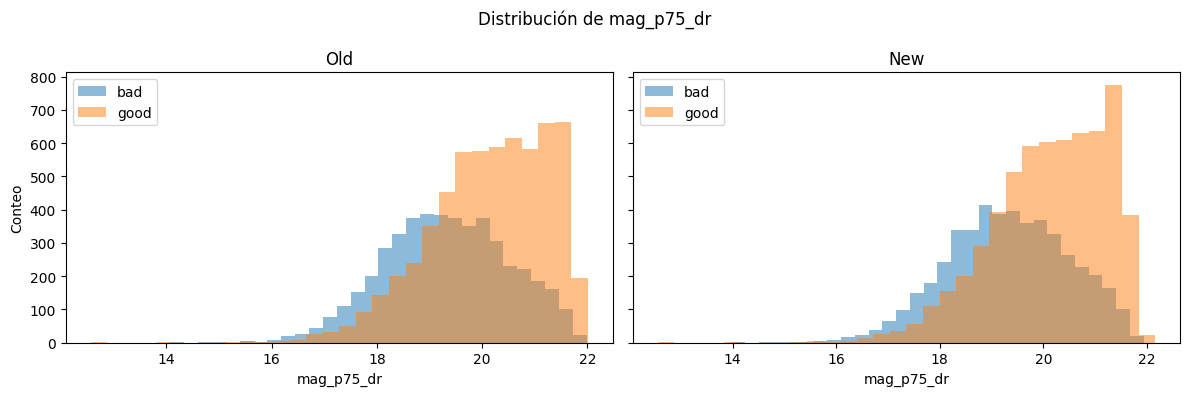

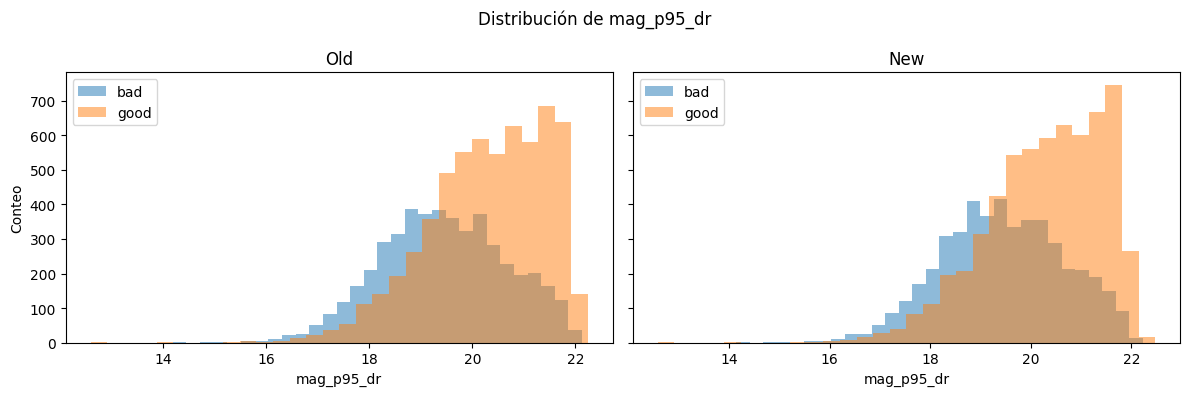

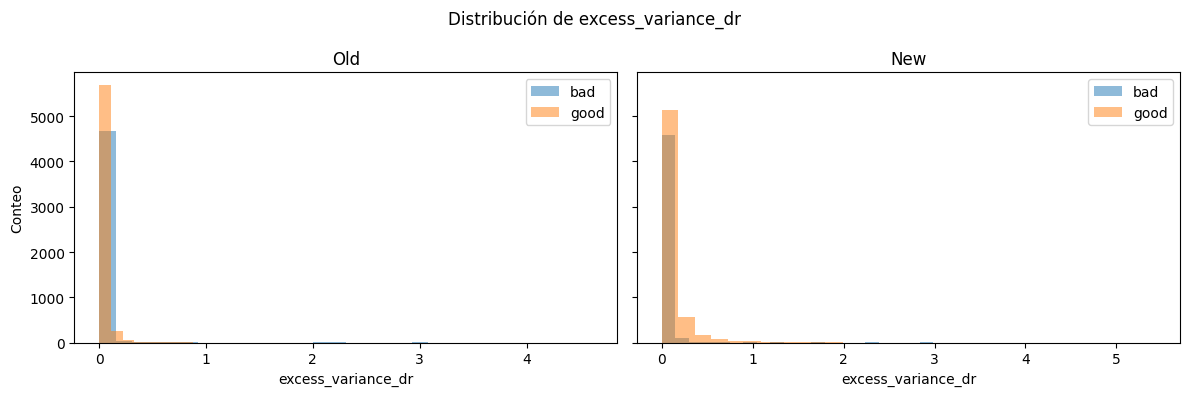

In [74]:
if "fid" in df_new.columns:
    fids = sorted(df_new["fid"].unique())
    for feature in alert_features + dr_features:
        for fid in fids:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
            # Old
            plot_hist_subplot(axes[0], df_old, fid, feature, "Old")
            # New
            plot_hist_subplot(axes[1], df_new, fid, feature, "New")
            plt.suptitle(f"Distribución de {feature} — Canal {fid}", y=1.02)
            plt.tight_layout()
            plt.show()
else:
    # Caso sin canal: comparación global
    for feature in alert_features + dr_features:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
        # Old
        counts_old = {lbl: df_old[df_old["label"]==lbl][feature].dropna() 
                      for lbl in df_old["label"].unique()}
        for lbl, data in counts_old.items():
            axes[0].hist(data, bins=30, alpha=0.5, label=lbl)
        axes[0].set_title("Old")
        axes[0].set_xlabel(feature)
        axes[0].set_ylabel("Conteo")
        axes[0].legend()

        # New
        counts_new = {lbl: df_new[df_new["label"]==lbl][feature].dropna() 
                      for lbl in df_new["label"].unique()}
        for lbl, data in counts_new.items():
            axes[1].hist(data, bins=30, alpha=0.5, label=lbl)
        axes[1].set_title("New")
        axes[1].set_xlabel(feature)
        axes[1].legend()

        plt.suptitle(f"Distribución de {feature}")
        plt.tight_layout()
        plt.show()



In [75]:
def compute_auc(df, features):
    y = (df['label'] == 'good').astype(int)
    results = []
    for feat in features:
        mask = df[feat].notna()
        if mask.sum() > 0:
            auc = roc_auc_score(y[mask], df.loc[mask, feat])
            results.append((feat, auc))
    return sorted(results, key=lambda x: x[1], reverse=True)

In [85]:
features = alert_features + dr_features + delight_features
# Calcular AUC para ambos datasets
auc_new = compute_auc(df_new, features)
auc_old = compute_auc(df_old, features)

# Unir resultados en un DataFrame para comparar
df_auc = pd.DataFrame({
    'feature': [f for f, _ in auc_new],
    'auc_new': [a for _, a in auc_new],
    'auc_old': [dict(auc_old).get(f, None) for f, _ in auc_new]
})

# Mostrar resultados
df_auc['diff'] = df_auc['auc_new'] - df_auc['auc_old']

In [86]:
df_auc

,feature,auc_new,auc_old,diff
0,mag_p95_dr,0.700398,0.699456,0.000942
1,mag_p75_dr,0.697895,0.697404,0.000491
2,mag_max_dr,0.694721,0.693688,0.001034
3,mag_p50_dr,0.694284,0.695469,-0.001186
4,excess_variance_dr,0.692793,0.603941,0.088852
5,mag_p25_dr,0.684463,0.693122,-0.008660
6,mag_p05_dr,0.655455,0.689278,-0.033823
7,distance_delight,0.647043,0.647043,0.000000
8,mag_min_dr,0.645090,0.705129,-0.060039
9,excess_variance_alert,0.579140,0.579140,0.000000


In [87]:
total_diff = df_auc['diff'].sum()
print(f"Suma total de diff: {total_diff:.3f}")

Suma total de diff: -0.015


In [88]:
from scipy.stats import ttest_ind

In [89]:
# Función para realizar Welch t-test
def welch_t_test(df, feature):
    good = df[df['label']=='good'][feature].dropna()
    bad  = df[df['label']=='bad'][feature].dropna()
    stat, pval = ttest_ind(good, bad, equal_var=False)
    return stat, pval, len(good), len(bad)

# Calcular tests para nuevos y antiguos
results = []
for feat in features:
    stat_new, p_new, n_good_new, n_bad_new = welch_t_test(df_new, feat)
    stat_old, p_old, n_good_old, n_bad_old = welch_t_test(df_old, feat)
    results.append({
        "feature": feat,
        "t_stat_new": stat_new,
        "p_val_new": p_new,
        "n_good_new": n_good_new,
        "n_bad_new": n_bad_new,
        "t_stat_old": stat_old,
        "p_val_old": p_old,
        "n_good_old": n_good_old,
        "n_bad_old": n_bad_old,
        "signif_new": p_new < 0.05,
        "signif_old": p_old < 0.05
    })

# Resultados en DataFrame
df_ttests = pd.DataFrame(results)
df_ttests = df_ttests.sort_values("p_val_new")

In [90]:
df_ttests

,feature,t_stat_new,p_val_new,n_good_new,n_bad_new,t_stat_old,p_val_old,n_good_old,n_bad_old,signif_new,signif_old
16,mag_p95_dr,37.103506,3.037390e-282,6061,4738,36.921438,1.161857e-279,6061,4738,True,True
15,mag_p75_dr,36.573445,8.854999e-275,6061,4738,36.512014,6.118977e-274,6061,4738,True,True
14,mag_p50_dr,35.787041,8.393177e-264,6061,4738,36.111279,2.362360e-268,6061,4738,True,True
11,mag_max_dr,35.698386,1.729436e-262,6061,4738,35.538561,2.804541e-260,6061,4738,True,True
13,mag_p25_dr,33.692319,1.543059e-235,6061,4738,35.619452,1.476568e-261,6061,4738,True,True
9,n_points_dr,-29.884111,3.461456e-187,6061,4738,-27.695829,5.800962e-162,6061,4738,True,True
12,mag_p05_dr,28.046936,1.803890e-166,6061,4738,34.907724,7.409080e-252,6061,4738,True,True
10,mag_min_dr,26.025995,1.612209e-144,6061,4738,38.525351,4.198839e-303,6061,4738,True,True
17,excess_variance_dr,18.954706,7.788181e-79,6061,4738,4.741109,2.167358e-06,6061,4738,True,True
3,mag_p05_alert,-16.676246,1.241393e-61,6061,4738,-16.676246,1.241393e-61,6061,4738,True,True


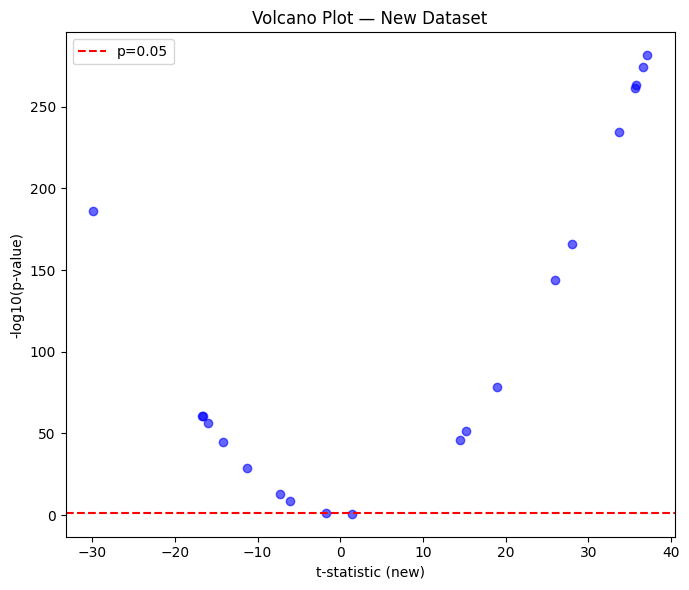

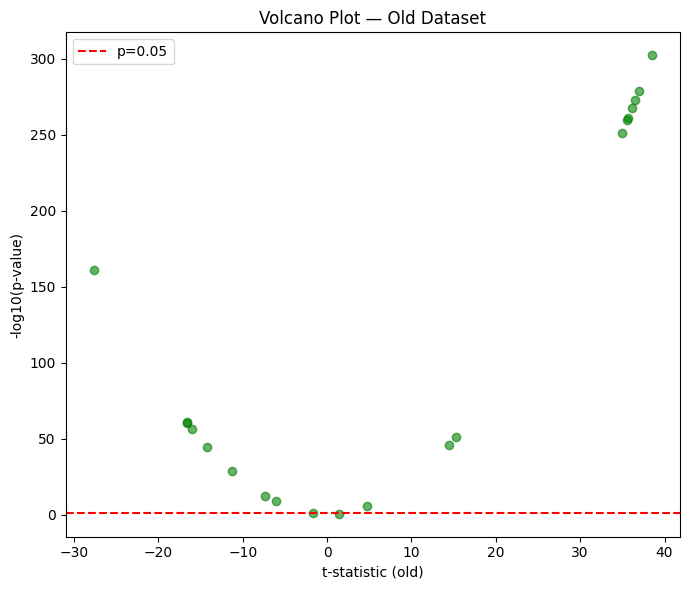

In [91]:
plt.figure(figsize=(7,6))
x = df_ttests['t_stat_new']
y = -np.log10(df_ttests['p_val_new'])
plt.scatter(x, y, c='blue', alpha=0.6)
plt.axhline(-np.log10(0.05), color='red', linestyle='--', label='p=0.05')
plt.xlabel('t-statistic (new)')
plt.ylabel('-log10(p-value)')
plt.title('Volcano Plot — New Dataset')
plt.legend()
plt.tight_layout()
plt.show()

# Volcano plot para OLD
plt.figure(figsize=(7,6))
x = df_ttests['t_stat_old']
y = -np.log10(df_ttests['p_val_old'])
plt.scatter(x, y, c='green', alpha=0.6)
plt.axhline(-np.log10(0.05), color='red', linestyle='--', label='p=0.05')
plt.xlabel('t-statistic (old)')
plt.ylabel('-log10(p-value)')
plt.title('Volcano Plot — Old Dataset')
plt.legend()
plt.tight_layout()
plt.show()